In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report


# Step 1: Load the dataset
data = pd.read_csv("Crop_Yield_Prediction.csv")  



In [19]:
data.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Yield
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice,7000
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice,5000
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice,7000
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice,7000
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice,120000


In [20]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   object 
 8   Yield        2200 non-null   int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 154.8+ KB


In [21]:
data.isnull().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
Yield          0
dtype: int64

In [22]:
data.duplicated().sum()

0

In [23]:
data.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Yield
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,2689.228182
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,3710.361267
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,2.000000
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,950.000000
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,1825.000000
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,3500.000000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,120000.000000


In [24]:
data['Crop'].value_counts()

Crop
Rice           100
Maize          100
Jute           100
Cotton         100
Coconut        100
Papaya         100
Orange         100
Apple          100
Muskmelon      100
Watermelon     100
Grapes         100
Mango          100
Banana         100
Pomegranate    100
Lentil         100
Blackgram      100
MungBean       100
MothBeans      100
PigeonPeas     100
KidneyBeans    100
ChickPea       100
Coffee         100
Name: count, dtype: int64

In [25]:
# Step 2: Preprocess the data
# assigning numerical values to crop type for better processing
label_encoder = LabelEncoder()
data['Crop'] = label_encoder.fit_transform(data['Crop'])

# Spliting features and target variable
X = data[['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature','Humidity','pH_Value','Rainfall']]  # Features
y = data['Crop']  # Target

# Scale the data for better SVM performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Converting scaled data back to DataFrame to maintain feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)


# Step 3: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=106,shuffle=True)

# Step 4: Train the SVM model
#This model is used in the function below
model = SVC(kernel='linear', random_state=106)
model.fit(X_train, y_train)

# Step 5: Make predictions
y_pred = model.predict(X_test)



# Step 6: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))





Accuracy: 0.98

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        22
           2       1.00      1.00      1.00        17
           3       1.00      1.00      1.00        31
           4       1.00      1.00      1.00        31
           5       1.00      1.00      1.00        26
           6       1.00      1.00      1.00        25
           7       1.00      1.00      1.00        23
           8       0.82      0.93      0.87        29
           9       0.93      1.00      0.96        25
          10       0.96      1.00      0.98        25
          11       1.00      1.00      1.00        16
          12       1.00      1.00      1.00        19
          13       1.00      0.97      0.99        39
          14       1.00      1.00      1.00        26
          15       1.00      1.00      1.00        30
          16       1.00      1.00      1.

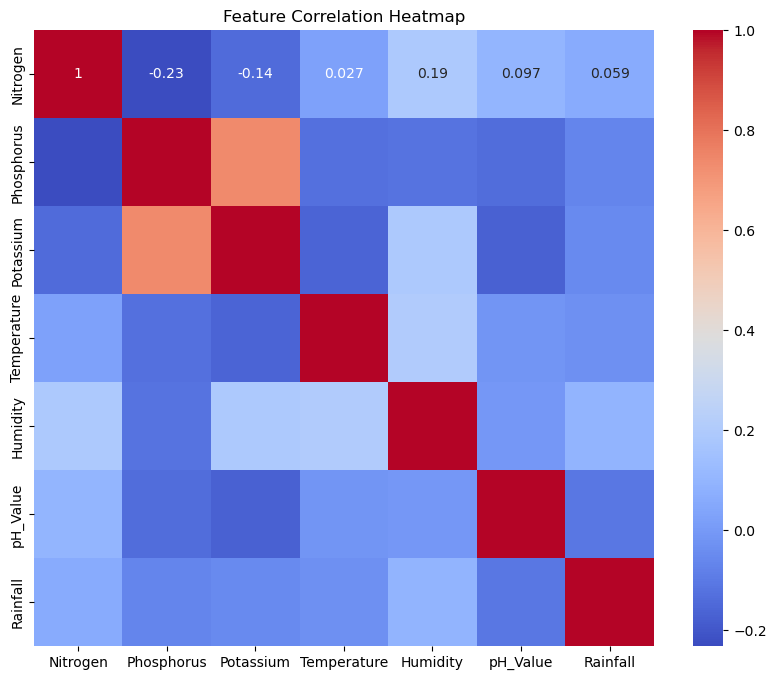

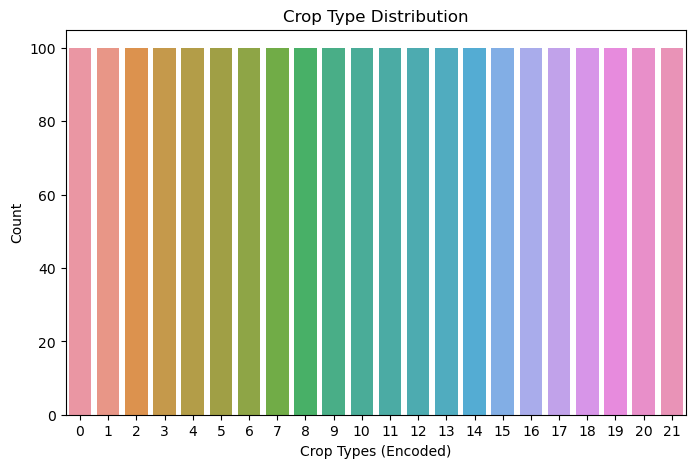

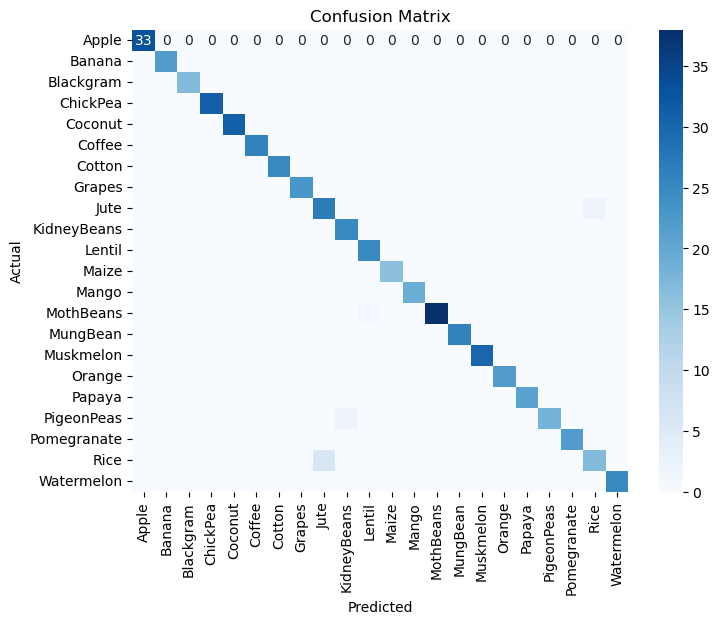

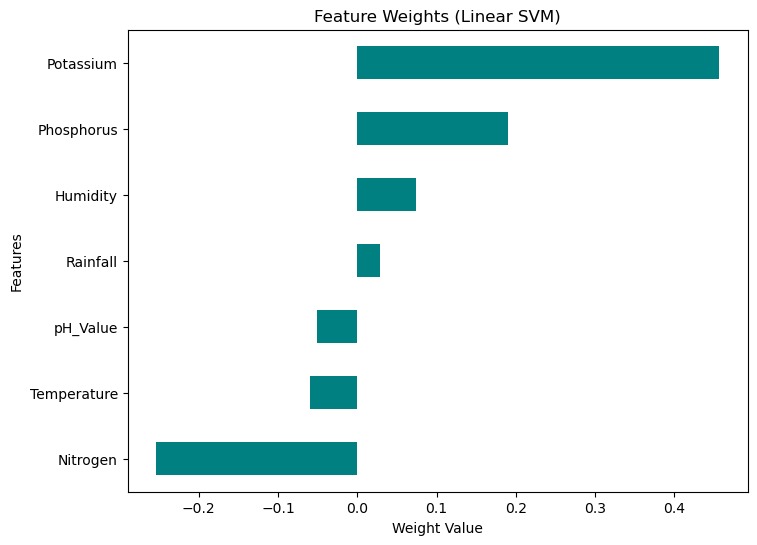

In [26]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1: Visualize feature correlations
plt.figure(figsize=(10, 8))
sns.heatmap(X_scaled_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 2: Class distribution of Crop types
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Crop Type Distribution")
plt.xlabel("Crop Types (Encoded)")
plt.ylabel("Count")
plt.show()

# Step 4: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 5: Visualize feature weights (only for linear SVM)
if model.kernel == 'linear':
    weights = model.coef_[0]
    feature_importance = pd.Series(weights, index=X.columns).sort_values()
    plt.figure(figsize=(8, 6))
    feature_importance.plot(kind='barh', color='teal')
    plt.title("Feature Weights (Linear SVM)")
    plt.xlabel("Weight Value")
    plt.ylabel("Features")
    plt.show()


In [27]:
# Step 7: Recommend crops based on user input
# This can be replaced by user inputting the values dynamically and the attributes being scraped from the web
def recommend_crop(Nitrogen, Phosphorus, Potassium, Temperature,Humidity,pH_Value,Rainfall):
    #soil_type_encoded = label_encoder.transform([soil_type])[0]
    user_input = scaler.transform([[Nitrogen, Phosphorus, Potassium, Temperature,Humidity,pH_Value,Rainfall]])
    prediction = model.predict(user_input)
    
    #crop_name = label_encoder.inverse_transform(prediction)
    #return crop_name[0]
    try:
        crop_name = label_encoder.inverse_transform(prediction)  # Returns an array of crop names
        return crop_name[0]  # Return the first crop name as a string
    except ValueError:
        return f"Unknown prediction: {prediction[0]}"

# Example usage
print("\nCrop Recommendation:")
recommended_crop = recommend_crop(Nitrogen=15, Phosphorus=35, Potassium=60, Temperature=15.5987,Humidity=88.2547,pH_Value=7.2834,Rainfall=290.3897)
print(f"Recommended Crop: {recommended_crop}")



Crop Recommendation:
Recommended Crop: Coconut


C:\Users\Mayan\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
